<a href="https://colab.research.google.com/github/francodem/chollet_dl_with_python/blob/main/DPB_deep_learning_for_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning with Python: Chapter 10 - Deep learning for timeseries

## This chapter covers
- Examples of ML tasks that involve timeseries data
- Understanding recurrent neural networks (RNNs)
- Applying RNNs to a temperature-forecasting example
- Advanced RNN usage patterns

In [1]:
# Download the dataset
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2025-02-12 03:56:09--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.177.105, 52.217.125.0, 16.182.71.176, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.177.105|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  47.8MB/s    in 0.3s    

2025-02-12 03:56:09 (47.8 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [2]:
# Let's look the data
import os
fname = os.path.join('jena_climate_2009_2016.csv')

with open(fname) as f:
  data = f.read()

lines = data.split('\n')
header = lines[0].split(',')
lines = lines[1:]

print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [3]:
# Conver to a numpy arrays
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header)-1))

for i, line in enumerate(lines):
  values = [float(x) for x in line.split(',')[1:]]
  temperature[i] = values[1]
  raw_data[i, :] = values[:]

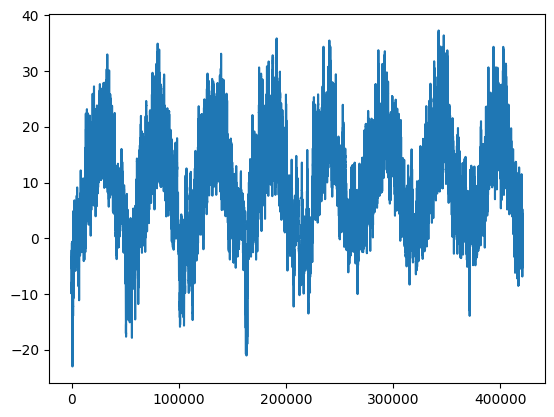

In [4]:
# Show the plot
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

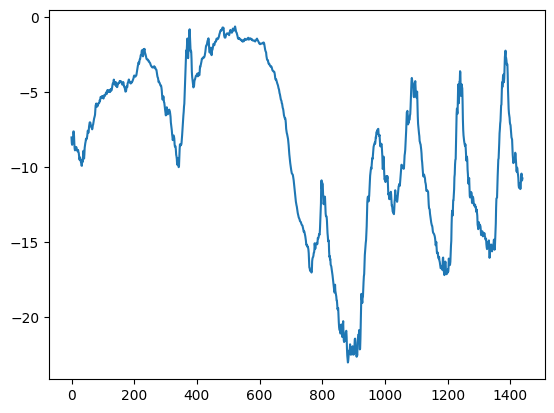

In [5]:
# Plot the first 10 days of the temperature timeseries
# ((1440 datapoints * 10 min) / 60 min) / 24 h = 9.72 days
plt.plot(range(1440), temperature[:1440])

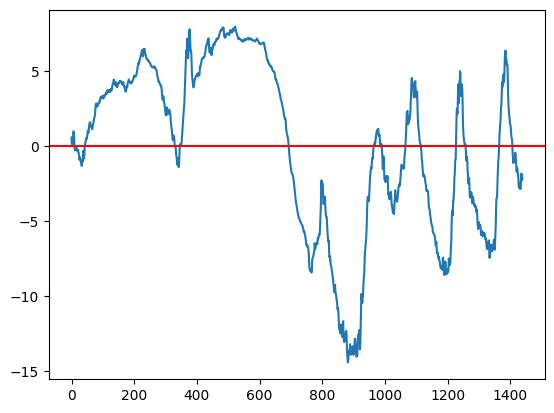

In [6]:
# Centering the distribution in 0 in y
temperature_aux = temperature[:1440]
mean_of_temp = temperature_aux.mean(axis=0)
temperature_aux -= mean_of_temp
plt.plot(range(len(temperature_aux[:1440])), temperature_aux)
plt.axhline(y=0, color='r', linestyle='-')

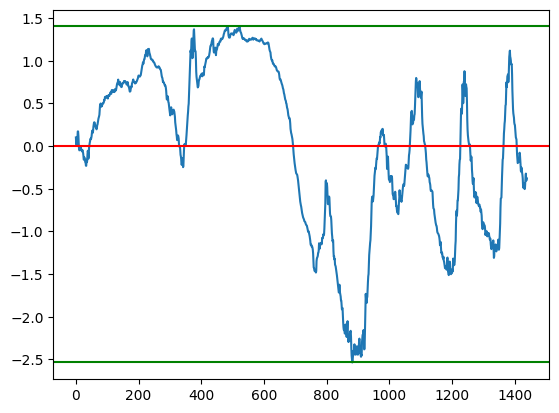

In [7]:
# Centering and scaling the data (normalization)
std_of_temperature_aux = temperature_aux.std(axis=0)
temperature_aux /= std_of_temperature_aux
plt.plot(range(len(temperature_aux[:1440])), temperature_aux)
plt.axhline(y=0, color='r', linestyle='-')
plt.axhline(y=temperature_aux.max(), color='g', linestyle='-')
plt.axhline(y=temperature_aux.min(), color='g', linestyle='-')

In [8]:
# Data split
# Important[!] Always split the data in this pattern for timeseries:
# First 50% for training, following 25% for testing and the last 25% for validation.
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print("num_train_samples: ", num_train_samples)
print("num_val_samples: ", num_val_samples)
print("num_test_samples: ", num_test_samples)

num_train_samples:  210225
num_val_samples:  105112
num_test_samples:  105114


In [10]:
# Preparing the data

# Removing the bias (mean) and centering to zero
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean

# Normalizing data with minus std
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [28]:
seq = np.arange(10)
seq[3:]

array([3, 4, 5, 6, 7, 8, 9])

In [36]:
# Will be necessary to use 'timeseries_dataset_from_array()' function from Keras, so let's try an example
import numpy as np
from tensorflow import keras

# Generate a random array
int_sequence = np.arange(10)

# Generate a dummy dataset
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

In [44]:
# Show the dummy datasset to see the sequences and their targets
for inputs, targets in dummy_dataset:
  for i in range(inputs.shape[0]):
    print("Sequence  | Target")
    print([int(x) for x in inputs[i]], "   ", int(targets[i]))

Sequence  | Target
[0, 1, 2]     3
Sequence  | Target
[1, 2, 3]     4
Sequence  | Target
[2, 3, 4]     5
Sequence  | Target
[3, 4, 5]     6
Sequence  | Target
[4, 5, 6]     7


In [47]:
# Let's build our training, validation and testing datasets

# 6 datapoints per hour
sampling_rate = 6

# 5 days of window = 120 h
sequence_length = 120

# time window to predict = 24 h
delay = sampling_rate * (sequence_length + 24 - 1)

# batch size
batch_size = 256

In [56]:
# taining set
train_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

In [55]:
# validation set
val_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples+num_val_samples,
)

In [54]:
# test set
test_dataset = keras.utils.timeseries_dataset_from_array(
    data=raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples+num_val_samples,
)

In [59]:
# Inspecting the output of one of our datasets
for samples, targets in train_dataset:
  print("Samples shape: ", samples.shape)
  print("Targets shape: ", targets.shape)
  break

Samples shape:  (256, 120, 14)
Targets shape:  (256,)
